In [57]:
import pandas as pd
df=pd.read_csv("/content/sample_data/Walmart Data Analysis and Forcasting.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [58]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [83]:
display(df.head())

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,-1.942666,05-02-2010,1.062778,0.693147,-1.017966,-1.683544,1.006528,2.313129
1,-1.942666,12-02-2010,1.060635,1.098612,-1.204376,-1.732738,1.009450,2.313129
2,-1.942666,19-02-2010,1.023306,0.693147,-1.135341,-1.802251,1.010391,2.313129
3,-1.942666,26-02-2010,0.757367,0.693147,-0.799809,-1.706104,1.011002,2.313129
4,-1.942666,05-03-2010,0.950729,0.693147,-0.806467,-1.574543,1.011613,2.313129


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Day           6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(2)
memory usage: 477.7 KB


In [60]:
df.isnull()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6430,False,False,False,False,False,False,False,False,False,False,False
6431,False,False,False,False,False,False,False,False,False,False,False
6432,False,False,False,False,False,False,False,False,False,False,False
6433,False,False,False,False,False,False,False,False,False,False,False


In [61]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
Year,0
Month,0


In [62]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
file_path='/content/sample_data/Walmart Data Analysis and Forcasting.csv'
walmart_data=pd.read_csv(file_path)

In [63]:
numerical_columns=['Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']
walmart_data.dropna(subset=numerical_columns,inplace=True)
minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()

In [64]:
walmart_data['Holiday_Flag_MinMax']=minmax_scaler.fit_transform(walmart_data[['Holiday_Flag']])
walmart_data['Temperature_MinMax']=minmax_scaler.fit_transform(walmart_data[['Temperature']])
walmart_data['Fuel_Price_MinMax']=minmax_scaler.fit_transform(walmart_data[['Fuel_Price']])
walmart_data['CPI_MinMax']=minmax_scaler.fit_transform(walmart_data[['CPI']])
walmart_data['Unemployment_MinMax']=minmax_scaler.fit_transform(walmart_data[['Unemployment']])

walmart_data['Holiday_Flag_Standard']=standard_scaler.fit_transform(walmart_data[['Holiday_Flag']])
walmart_data['Temperature_Standard']=standard_scaler.fit_transform(walmart_data[['Temperature']])
walmart_data['Fuel_Price_Standard']=standard_scaler.fit_transform(walmart_data[['Fuel_Price']])
walmart_data['CPI_Standard']=standard_scaler.fit_transform(walmart_data[['CPI']])
walmart_data['Unemployment_Standard']=standard_scaler.fit_transform(walmart_data[['Unemployment']])

In [65]:
walmart_data[['Holiday_Flag','Holiday_Flag_MinMax','Holiday_Flag_Standard']].head()

,Holiday_Flag,Holiday_Flag_MinMax,Holiday_Flag_Standard
0,0,0.0,-0.274204
1,1,1.0,3.646917
2,0,0.0,-0.274204
3,0,0.0,-0.274204
4,0,0.0,-0.274204


In [66]:
walmart_data[['Temperature','Temperature_MinMax','Temperature_Standard']].head()

,Temperature,Temperature_MinMax,Temperature_Standard
0,42.31,0.434149,-0.995136
1,38.51,0.396967,-1.201170
2,39.93,0.410861,-1.124178
3,46.63,0.476419,-0.760907
4,46.50,0.475147,-0.767955


In [67]:
walmart_data[['Fuel_Price' ,'Fuel_Price_MinMax','Fuel_Price_Standard']].head()

,Fuel_Price,Fuel_Price_MinMax,Fuel_Price_Standard
0,2.572,0.050100,-1.713800
1,2.548,0.038076,-1.766089
2,2.514,0.021042,-1.840166
3,2.561,0.044589,-1.737766
4,2.625,0.076653,-1.598328


In [68]:
walmart_data[['CPI','CPI_MinMax','CPI_Standard']].head()

,CPI,CPI_MinMax,CPI_Standard
0,211.096358,0.840500,1.004175
1,211.242170,0.841941,1.007880
2,211.289143,0.842405,1.009074
3,211.319643,0.842707,1.009849
4,211.350143,0.843008,1.010624


In [69]:
walmart_data[['Unemployment','Unemployment_MinMax','Unemployment_Standard']].head()

,Unemployment,Unemployment_MinMax,Unemployment_Standard
0,8.106,0.405118,0.056964
1,8.106,0.405118,0.056964
2,8.106,0.405118,0.056964
3,8.106,0.405118,0.056964
4,8.106,0.405118,0.056964


Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Day             0
dtype: int64

Summary Statistics:
              Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment         Year  \
count  6435.000000  6435.000000  64

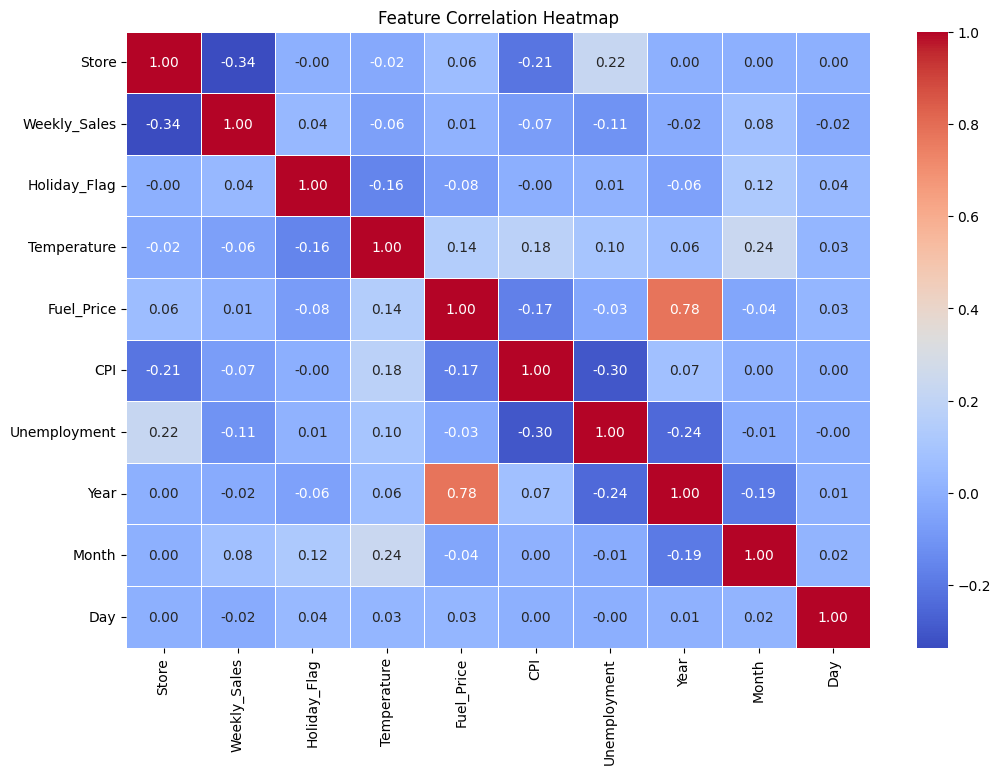

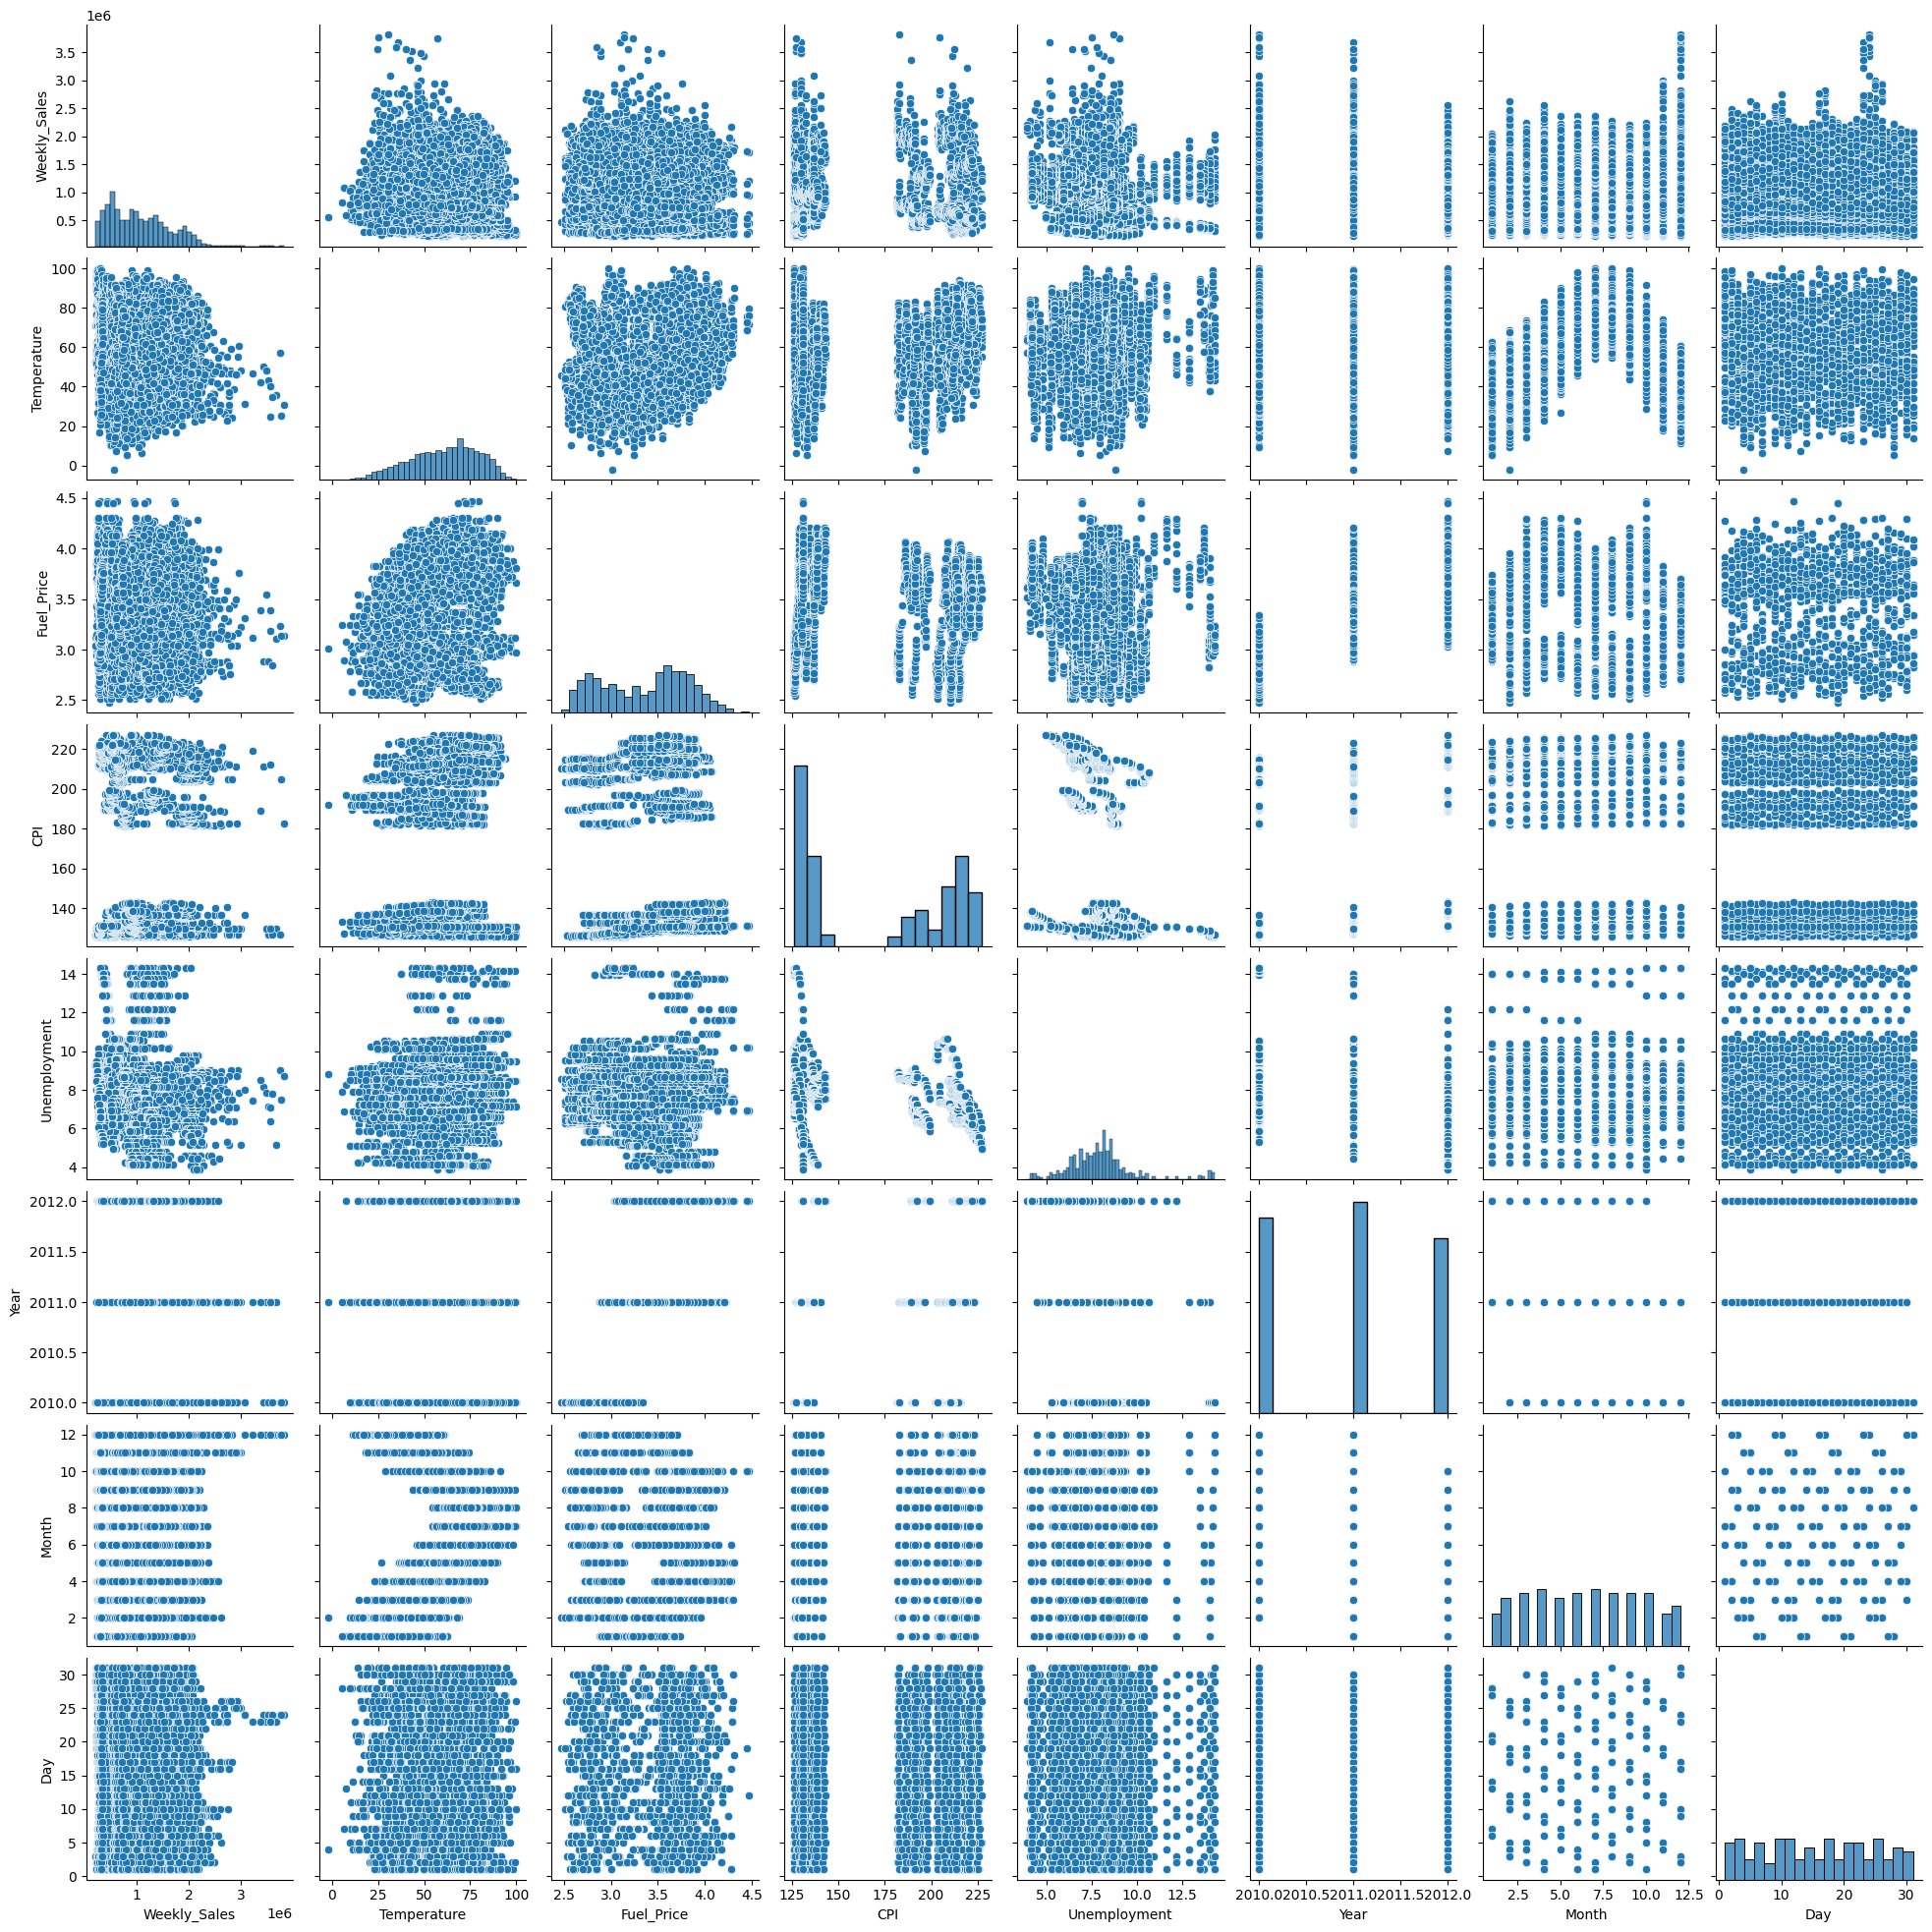

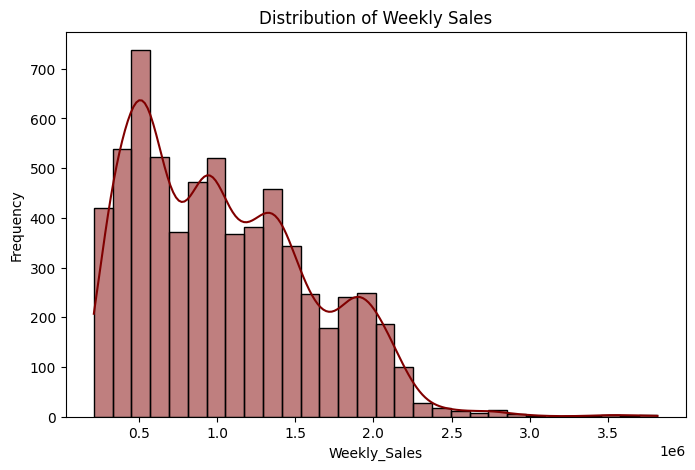

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/sample_data/Walmart Data Analysis and Forcasting.csv")

# Convert 'Date' column to datetime and extract Year, Month, Day
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe(include='all'))

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairplot for key variables (including new date features if desired, adjusting columns)
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']])
plt.show()

# Distribution of target variable (Weekly_Sales)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='maroon')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and Date
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1555
RMSE: 521597.6144


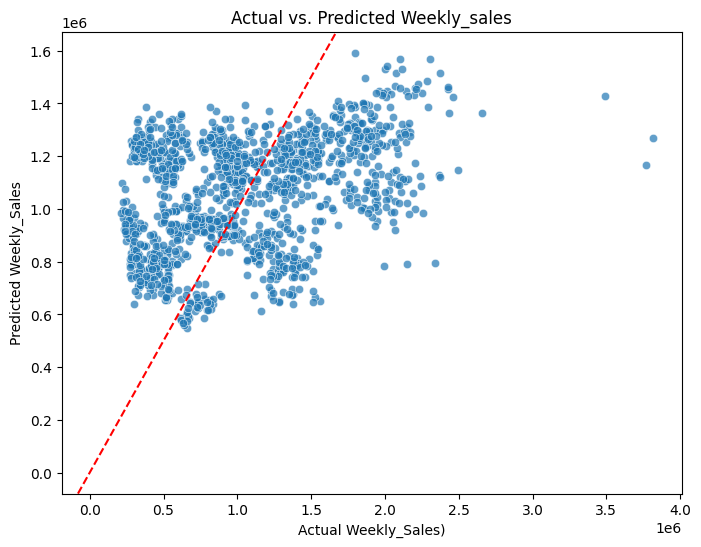

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("Actual Weekly_Sales)")
plt.ylabel("Predicted Weekly_Sales")
plt.title("Actual vs. Predicted Weekly_sales")
plt.axline([0,0],[1,1],color='red',linestyle='--')

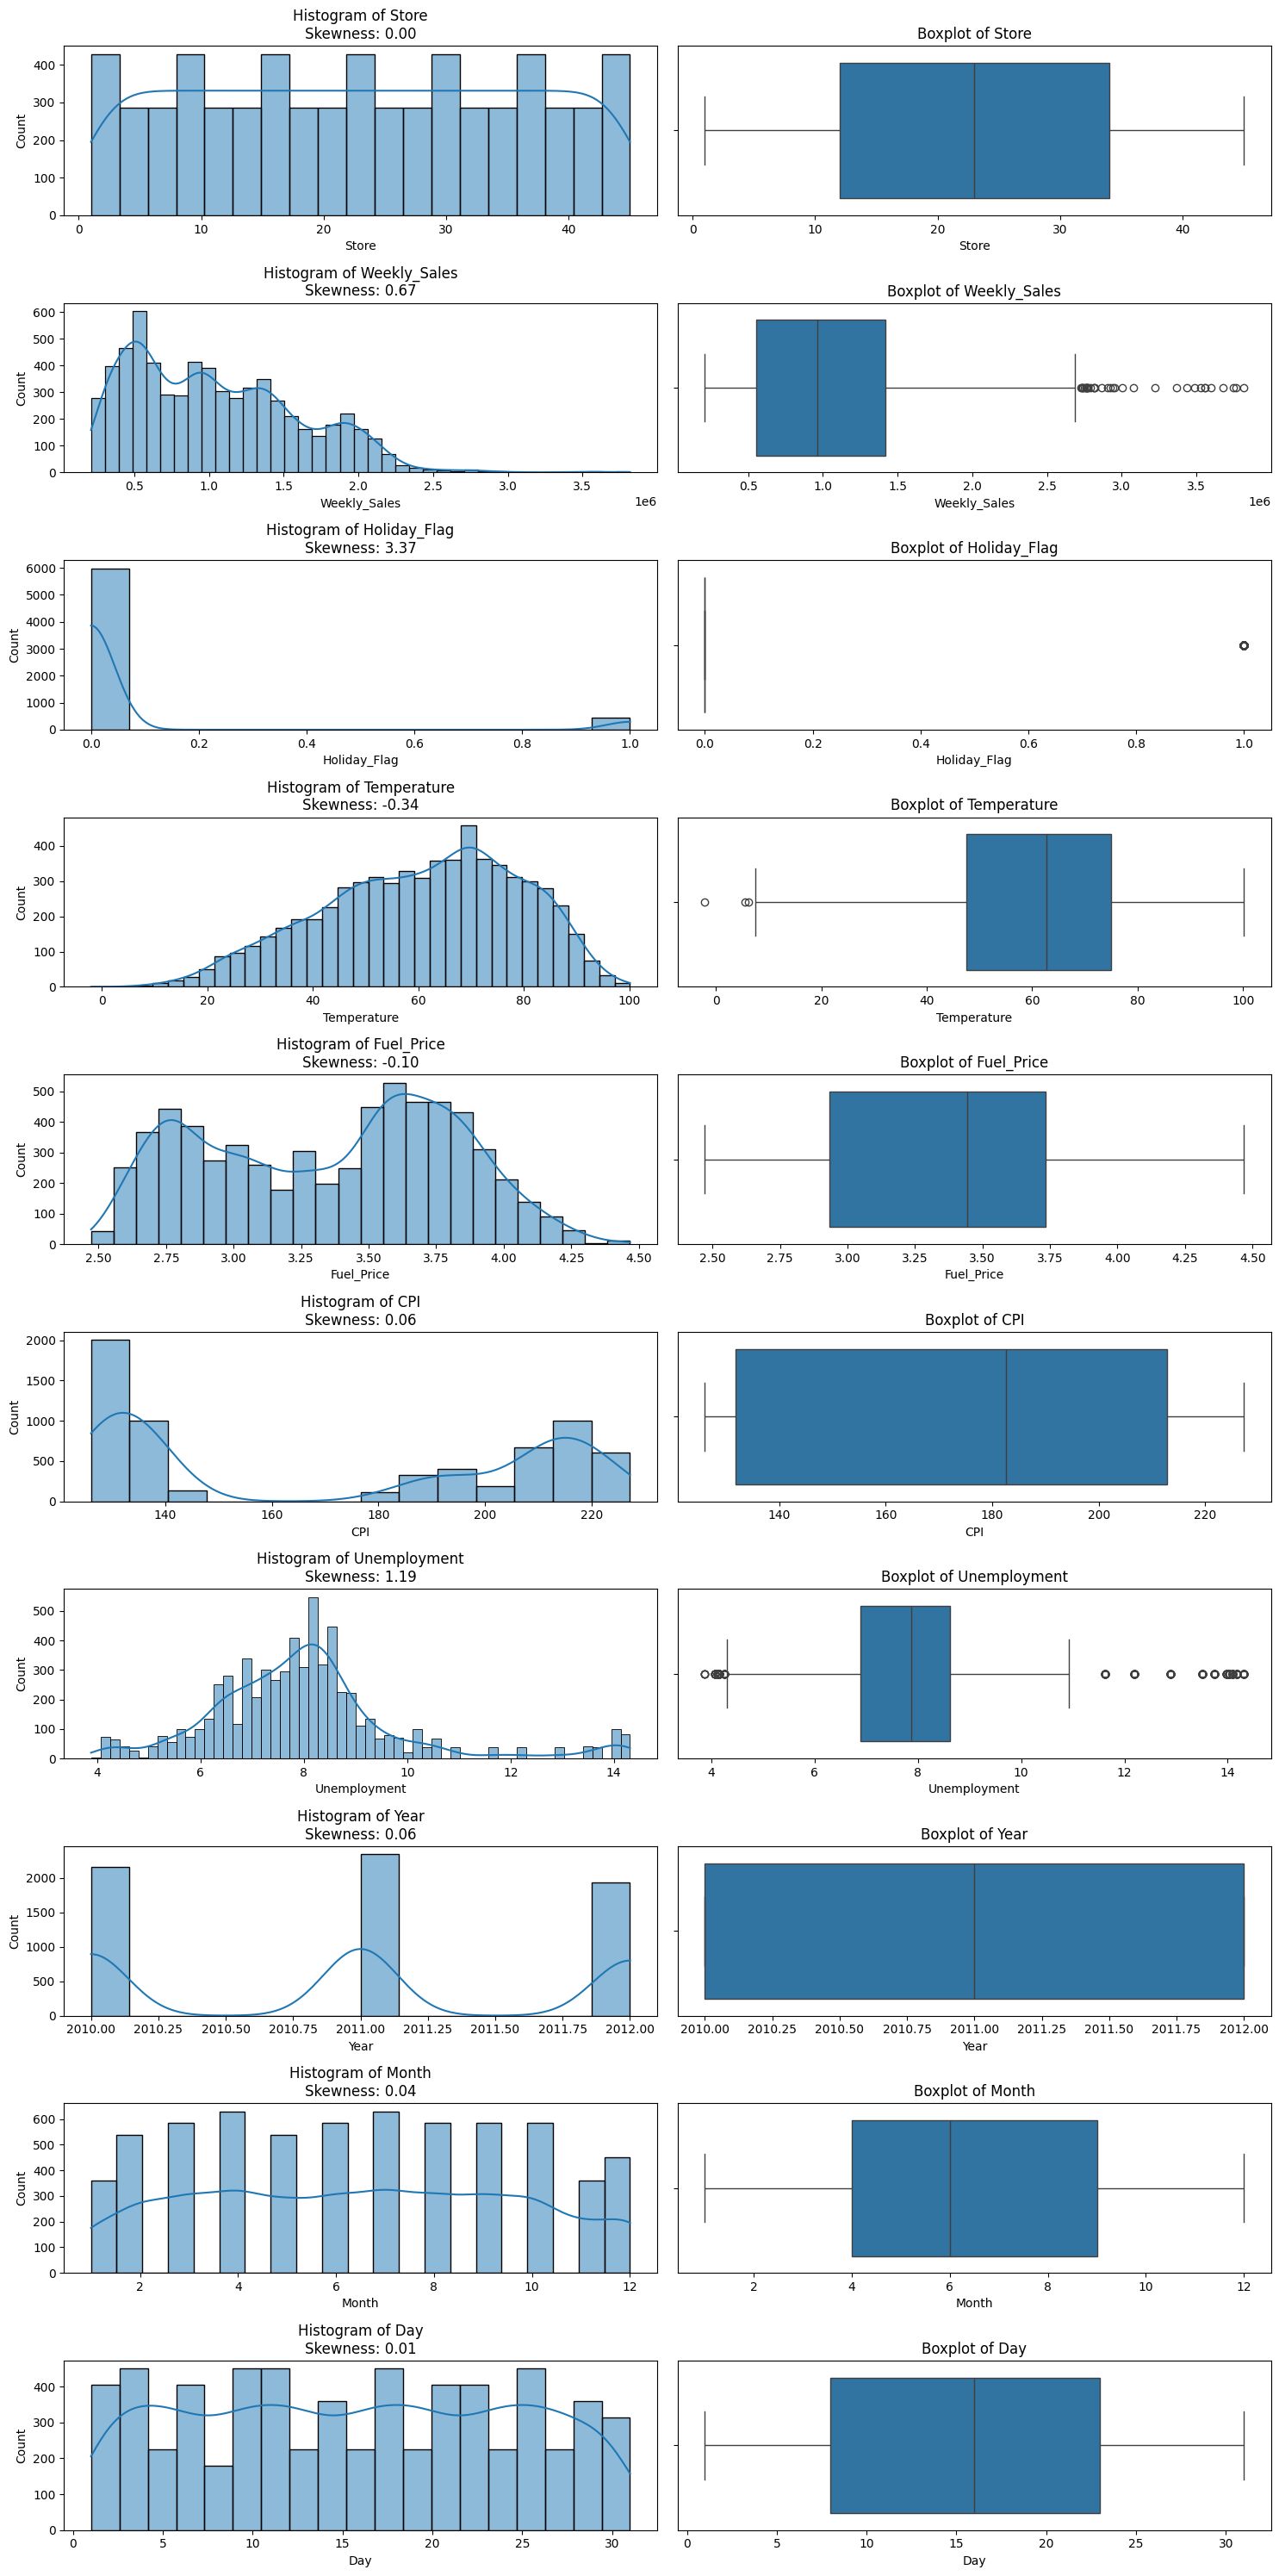

In [91]:
from scipy.stats import skew
skewness=df.skew(numeric_only=True)

#plot histograms
numeric_df = df.select_dtypes(include=['number'])
num_cols_to_plot = len(numeric_df.columns)
plt.figure(figsize=(15,num_cols_to_plot*3))

for i,col in enumerate(numeric_df.columns):
  plt.subplot(num_cols_to_plot,2,2*i+1)
  sns.histplot(numeric_df[col],kde=True)
  plt.title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')

  plt.subplot(num_cols_to_plot,2,2*i+2)
  sns.boxplot(x=numeric_df[col])
  plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [95]:
df.skew(numeric_only=True)

,0
Store,0.000000
Weekly_Sales,0.668362
Holiday_Flag,3.373499
Temperature,-0.336768
Fuel_Price,-0.096158
CPI,0.063492
Unemployment,1.188144
Year,0.062642
Month,0.039568
Day,0.008512


In [96]:
import numpy as np

skewed_cols=df.skew(numeric_only=True).abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly skewed columns:\n",highly_skewed)
print("Negatively skewed columns:\n",negatively_skewed)

Highly skewed columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [97]:
df[highly_skewed]=df[highly_skewed].apply(lambda x: np.log1p(x+1))

In [98]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [99]:
df.skew(numeric_only=True)

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.325604
Year,0.000000
Month,-0.140278
Day,-0.209117


In [103]:
#NOT NEEDED IG
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales","Date"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1336
RMSE: 0.9428


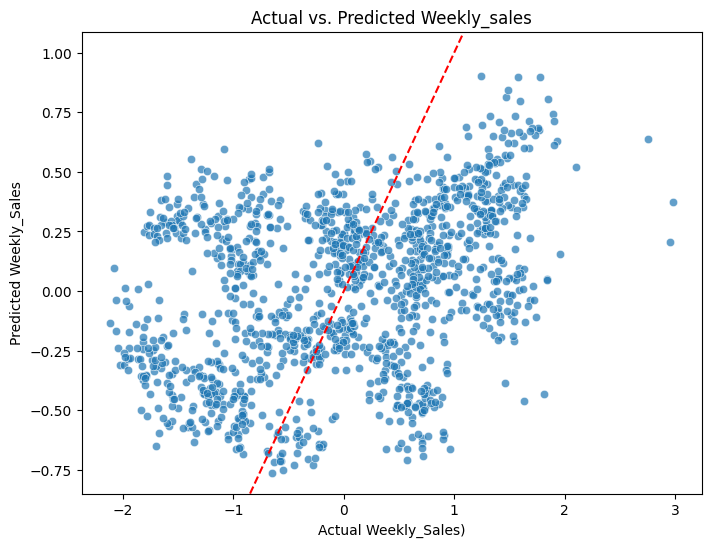

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("Actual Weekly_Sales)")
plt.ylabel("Predicted Weekly_Sales")
plt.title("Actual vs. Predicted Weekly_sales")
plt.axline([0,0],[1,1],color='red',linestyle='--')

In [102]:
from sklearn.ensemble import RandomForestRegressor

#train random forest
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#predictions&evaluations
y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9762
RMSE: 0.1563


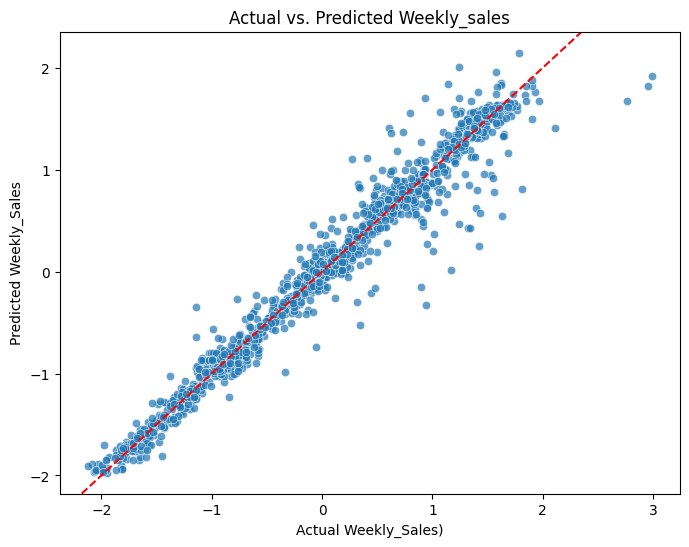

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("Actual Weekly_Sales)")
plt.ylabel("Predicted Weekly_Sales")
plt.title("Actual vs. Predicted Weekly_sales")
plt.axline([0,0],[1,1],color='red',linestyle='--')